
<p style="font-size:50px">
<span style="font-size:200px">
&#9703;
</span>
Héritage et polymorphisme
</p>

---



Sous-sections :
[Héritage](#heritage)&nbsp;|
[Surcharge de méthodes](#surcharge)&nbsp;|
[Le mot-clé super()](#super)&nbsp;|
[Polymorphisme](#polymorphisme)&nbsp;|
[Application aux polygones](#polygones)&nbsp;

<a id="heritage"></a>
### Héritage

Une sous-classe hérite des attributs et méthodes de ses parents :

In [1]:
class A:
    u = 'a'
    def une_methode(self):
        print('A')
class B(A):
    pass

In [2]:
B.__name__

'B'

In [3]:
un_b = B()
isinstance(un_b,B),isinstance(un_b,A),isinstance(un_b,object),isinstance(un_b,list)

(True, True, True, False)

In [4]:
B().u

'a'

In [5]:
B().une_methode()

A


<a id="surcharge"></a>
### Surcharge de méthodes

On peut réécrire un attribut ou une méthode dans la classe fille :

In [6]:
class A:
    u = 'a'
    def une_methode(self):
        print('A')
class B(A):
    u = 'b'
    def une_methode(self):
        print('B')

In [7]:
B().u

'b'

In [8]:
B().une_methode()

B


<a id="super"></a>
### Le mot-clé super()

__héritage multiple__

Une classe peut hériter de plusieurs classes, comme ici :


<img src="../images/heritage.png" width='100' alt="heritage"/>

In [9]:
 
class C:
    pass
class D(C):
    v = 'd'
    def une_methode(self):
        return 'D'
class F:
    v = 'f'
class G(C,F):
    pass
class E(B,D,G):
    pass

In [10]:
G.__bases__

(__main__.C, __main__.F)

__Method Resolution Order (MRO)__ 

En cas d'héritage multiple, 
les parents d'une classe sont ordonnés selon deux principes :
- recherche en profondeur d'abord, puis en largeur
- on ne garde que la dernière occurence visitée d'une classe

In [11]:
[cls.__name__ for cls in E.__mro__]

['E', 'B', 'A', 'D', 'G', 'C', 'F', 'object']

Cet ordre est utilisé pour chercher dans la hiérarchie quelle méthode ou quel attribut utiliser :

In [12]:
E.v

'd'

In [13]:
E.une_methode

<function __main__.B.une_methode(self)>

__le mot-clé super()__

`super()` permet de récupérer une référence vers le premier parent dans l'ordre MRO qui possède une méthode donnée

In [14]:
class U:
  def __init__(self):
    self.y = 'a'
class V:
  def __init__(self):
    self.y = 'b'
class W(U,V):
  def __init__(self, x):
    self.x = x
    super().__init__()

Par exemple ici, c'est la méthode d'initialisation `__init__` de la classe `A` qui est appelée :

In [15]:
W(4).__dict__

{'x': 4, 'y': 'a'}

<a id="polymorphisme"></a>
### Polymorphisme

Le polymorphisme est la capacité d'une référence à être rattachée à l'exécution à des objets de types différents. 

In [16]:
class Dog:
    def talk(self):
        print("woooff!")
class Cat: 
    def talk(self):
        print('Meeou!')
kitty = Cat()
nestor = Dog()
for animal in [kitty,nestor]:
    animal.talk()

Meeou!
woooff!


<a id="polygones"></a>
### Application aux polygones

Comme ce qui est commun à toutes les figures, c'est de pouvoir être dessiné sur une sous-figure (méthode `dessine_sur`),
on a créé dans le module `polygones` (fichier polygones.py) une classe abstraite `Figure` qui définit la méthode `dessine_sur`, et dont toutes les figures seront des sous-classes.

__Ajout d'une classe Cercle__

On veut maintenant ajouter une classe `Cercle`, qui représentera un cercle.

Pour dessiner un cercle, on peut utiliser la méthode `add_patch` de la classe `Axes` de Matplotlib, comme ici :

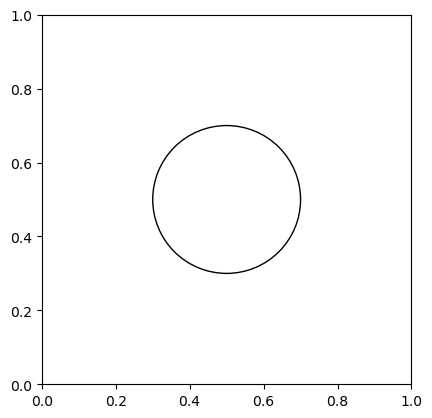

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
ax = plt.figure().gca()
ax.set_aspect('equal')
ax.add_patch(Circle((.5,.5),.2,fill=False))

Un cercle est une figure qui peut être dessinée, 
donc `Cercle` doit aussi être une sous-classe de `Figure`.

Compléter la définition de la classe `Cercle` ci-dessous :

In [ ]:
from polygones import Figure

class Cercle(Figure):
    def __init__(self, c, r):
        pass
        # <- a completer



Le code suivant doit utiliser le polymorphisme pour afficher plusieurs figures sur un même dessin :

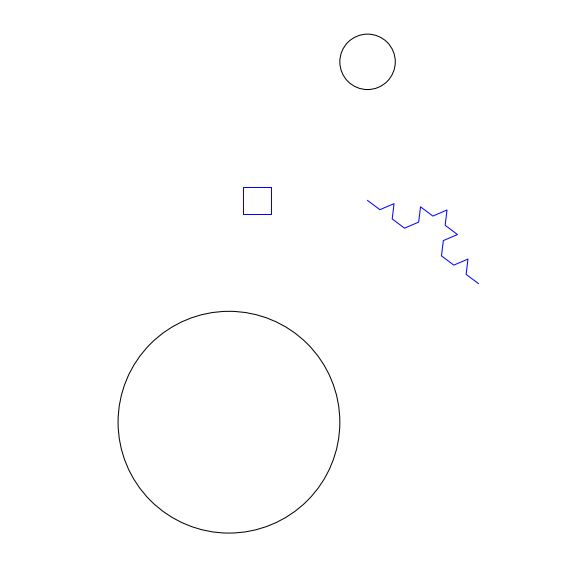

In [19]:
from polygones import Dessin, Point, Carre, Polygone, VonKoch
Polygone.lw = 1
Polygone.marker='-'
Polygone.couleur='blue'
dessin = Dessin()
for figure in [Cercle((3,8),1),Carre((-1,3),1),Cercle((-2,-5),4), VonKoch(Polygone([Point(3,3),Point(7,0)]),n_iter=2)]:
    dessin.dessine(figure)


__Exercice__.
Quel est l'ordre des classes parentes de la classe `Carre` ?

In [ ]:
# <- a completer

(polygones.Carre, polygones.Polygone, list, polygones.Figure, abc.ABC, object)

__Graphe des k voisins__

On veut maintenant créer un nouveau type de polygone appelé `KNeigbhorsGraph`, qui pour un nombre `k` donné trace le [graphe des $k$ plus proches voisins](https://en.wikipedia.org/wiki/Nearest_neighbor_graph) d'un ensemble de points.



Voici un exemple de code qui produirait un tel graphe à partir d'un ensemble `X` de coordonnées de points :

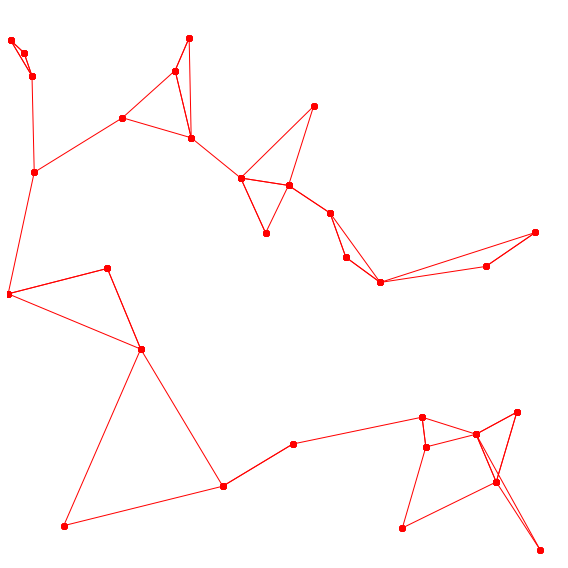

In [23]:
from cbp.similarity.measures import euclidean_sim
from cbp.algo.knn import kneighbors
from polygones import Polygone
k = 3
N = 30
X = np.random.uniform(-10,10,(N,2))
dessin = Dessin()
Polygone.marker='o-'
Polygone.couleur = 'red'
for p in X:
    indices = kneighbors(p,X,euclidean_sim,n_neighbors=k)
    debut = Point(p[0],p[1])
    for ind in indices:
        xi,yi = X[ind]
        fin = Point(xi,yi)
        dessin.dessine(Polygone([debut,fin]))


En s'inspirant de ce code, compléter la définition de la classe `KNeigbhorsGraph` ci-dessous :

In [ ]:
class KNeigbhorsGraph(list[Polygone], Figure):
    pass
    # <- a completer 
   

On doit pouvoir l'utiliser de la manière suivante pour dessiner le graphe des $3$ plus proches voisins d'un ensemble de points dont les coordonnées sont décrite par `X` :

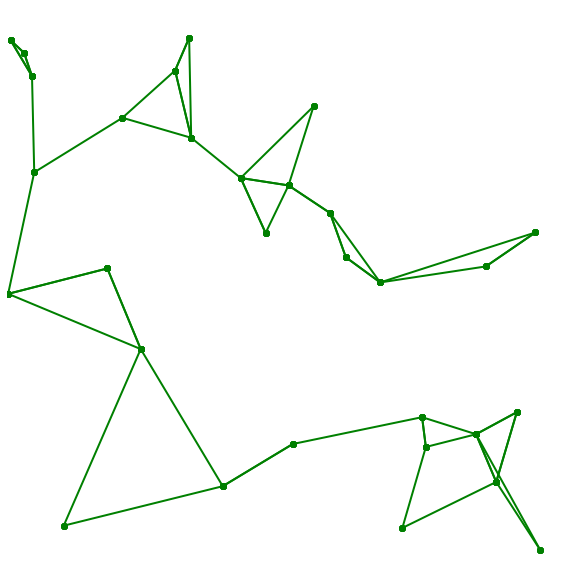

In [30]:
Polygone.couleur = 'green'
Polygone.lw = 2
Dessin().dessine(KNeigbhorsGraph(X,n_neighbors=3))